Data 03 Spearman correlation: 0.483, p-value=1.443e-02


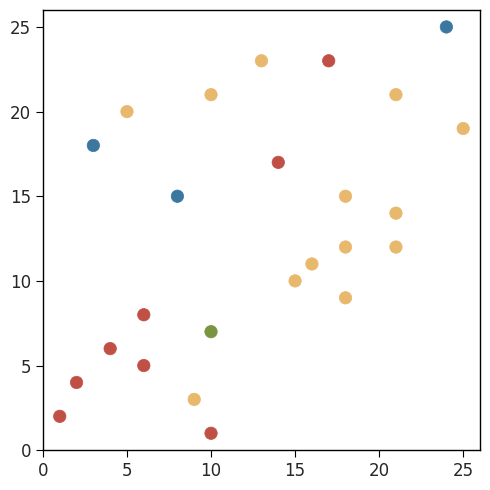

Data 10 Spearman correlation: 0.072, p-value=7.309e-01


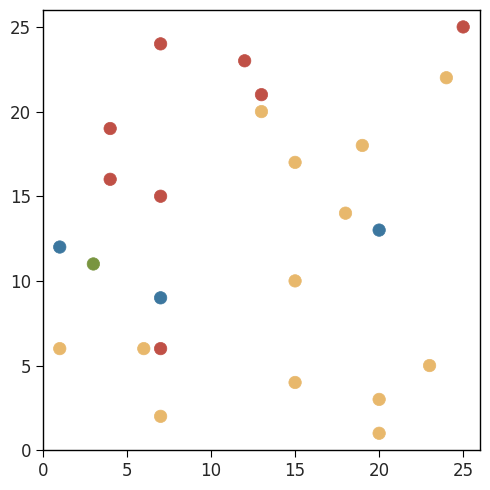

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

DATASETS = ["data03", "data10"]
DATASET_LABELS = {"data03": "Data 03", "data10": "Data 10"}
OUTPUT_CSV = "data03_data10_direction_temporal_rank_compare.csv"
OUTPUT_PNG_TEMPLATE = "{dataset}_direction_temporal_rank_scatter.png"
DIFF_RANK_SVG_TEMPLATE = "{dataset}_diff_rank.svg"

BASE_DIR = Path(".")
DIRECTION_BASE = BASE_DIR
TEMPORAL_BASE = BASE_DIR

newmethods = {
    "unitvelo_ind": "UniTVelo (ind)",
    "velovi": "veloVI",
    "cell2fate": "cell2fate",
    "latentvelo_std": "LatentVelo (std)",
    "pyrovelocity_m1": "Pyro-Velocity (m1)",
    "pyrovelocity_m2": "Pyro-Velocity (m2)",
    "sctour_mse": "scTour (MSE)",
    "sctour_nb": "scTour (NB)",
    "sctour_zinb": "scTour (ZINB)",
    "scvelo_dyn": "scVelo (dyn)",
    "unitvelo_uni": "UniTVelo (uni)",
    "deepvelo": "DeepVelo",
    "svelvetvae": "SvelvetVAE",
    "tivelo_std": "TIVelo (std)",
    "tivelo_simple": "TIVelo (simple)",
    "velocyto": "Velocyto",
    "veloae": "VeloAE",
    "velovae_std": "VeloVAE (std)",
    "velovae_fullvb": "VeloVAE (Full VB)",
    "kvelo": "  -velo",
    "celldancer": "cellDancer",
    "dynamo_m1": "Dynamo (m1)",
    "graphvelo_std": "GraphVelo (std)",
    "scvelo_stc": "scVelo (stc)",
    "sdevelo": "SDEvelo",
}

method_class = {
    "cell2fate": 1,
    "latentvelo_std": 1,
    "pyrovelocity_m1": 1,
    "pyrovelocity_m2": 1,
    "sctour_mse": 1,
    "sctour_nb": 1,
    "sctour_zinb": 1,
    "unitvelo_uni": 1,
    "unitvelo_ind": 2,
    "velovi": 2,
    "scvelo_dyn": 2,
    "deepvelo": 3,
    "svelvetvae": 3,
    "tivelo_std": 3,
    "tivelo_simple": 3,
    "velocyto": 3,
    "veloae": 3,
    "velovae_std": 3,
    "velovae_fullvb": 3,
    "kvelo": 3,
    "celldancer": 3,
    "dynamo_m1": 3,
    "graphvelo_std": 3,
    "scvelo_stc": 3,
    "sdevelo": 4,
}

class_colors = {
    1: "#C05046",
    2: "#3C779F",
    3: "#E8B86C",
    4: "#799540",
}


def get_metric_rank(data_dir, metric):
    data_path = Path(data_dir) / f"{metric}_df.csv"
    if not data_path.exists():
        raise FileNotFoundError(data_path)

    df = pd.read_csv(data_path)
    fold_columns = [col for col in df.columns if col != "Method"]
    metric_df = df[["Method"]].copy()
    metric_df[f"{metric}_mean"] = df[fold_columns].mean(axis=1)
    metric_df[f"{metric}_rank"] = metric_df[f"{metric}_mean"].rank(
        ascending=False, method="min"
    )
    return metric_df


def get_combined_rank(data_dir, metrics, rank_name):
    combined_df = None
    for metric in metrics:
        metric_df = get_metric_rank(data_dir, metric)
        if combined_df is None:
            combined_df = metric_df
        else:
            combined_df = combined_df.merge(metric_df, on="Method", how="inner")

    rank_columns = [f"{metric}_rank" for metric in metrics]
    combined_df[f"{rank_name}_mean_rank"] = combined_df[rank_columns].mean(axis=1)
    combined_df[f"{rank_name}_rank"] = combined_df[f"{rank_name}_mean_rank"].rank(
        ascending=True, method="min"
    )
    return combined_df


rank_compare_dfs = []
for dataset_name in DATASETS:
    direction_rank_df = get_combined_rank(
        DIRECTION_BASE / dataset_name,
        ["cbdir", "icvcoh"],
        "direction",
    )
    temporal_rank_df = get_combined_rank(
        TEMPORAL_BASE / dataset_name,
        ["cto", "tsc"],
        "temporal",
    )

    compare_df = direction_rank_df.merge(
        temporal_rank_df,
        on="Method",
        how="inner",
        suffixes=("_direction", "_temporal"),
    )
    compare_df["dataset"] = dataset_name
    compare_df["class"] = compare_df["Method"].map(method_class)
    compare_df["Method_mapped"] = compare_df["Method"].map(newmethods).fillna(compare_df["Method"])
    rank_compare_dfs.append(compare_df)

rank_compare_df = pd.concat(rank_compare_dfs, ignore_index=True)
rank_compare_df.to_csv(OUTPUT_CSV, index=False)

sns.set_style("white")

lims = [
    min(rank_compare_df["direction_rank"].min(), rank_compare_df["temporal_rank"].min()) - 1,
    max(rank_compare_df["direction_rank"].max(), rank_compare_df["temporal_rank"].max()) + 1,
]
ticks = np.arange(np.floor(lims[0]), np.ceil(lims[1]) + 1, 5)

for dataset_name in DATASETS:
    fig, ax = plt.subplots(figsize=(5, 5))
    plot_df = rank_compare_df[rank_compare_df["dataset"] == dataset_name].copy()
    rho, pval = spearmanr(plot_df["direction_rank"], plot_df["temporal_rank"])
    print(
        f"{DATASET_LABELS[dataset_name]} Spearman correlation: "
        f"{rho:.3f}, p-value={pval:.3e}"
    )

    sns.scatterplot(
        data=plot_df,
        x="direction_rank",
        y="temporal_rank",
        hue="class",
        palette=class_colors,
        s=80,
        edgecolor=None,
        linewidth=0.5,
        alpha=1.0,
        legend=False,
        ax=ax,
    )
    # ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, alpha=0.6)

    # ax.set_title(DATASET_LABELS[dataset_name], fontsize=13)
    ax.set_xlabel("", fontsize=12, labelpad=10)
    ax.set_ylabel("", fontsize=12, labelpad=10)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis="both", labelsize=12)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        length=5,
        color="black",
        top=False,
        right=False,
        bottom=True,
        left=True,
    )

    # for _, row in plot_df.iterrows():
    #     ax.text(
    #         row["direction_rank"] + 0.15,
    #         row["temporal_rank"],
    #         row["Method_mapped"],
    #         fontsize=7,
    #         alpha=0.7,
    #     )

    plt.tight_layout()
    plt.savefig(
        OUTPUT_PNG_TEMPLATE.format(dataset=dataset_name),
        format="png",
        bbox_inches="tight",
        dpi=150,
    )
    plt.show()
    plt.close(fig)


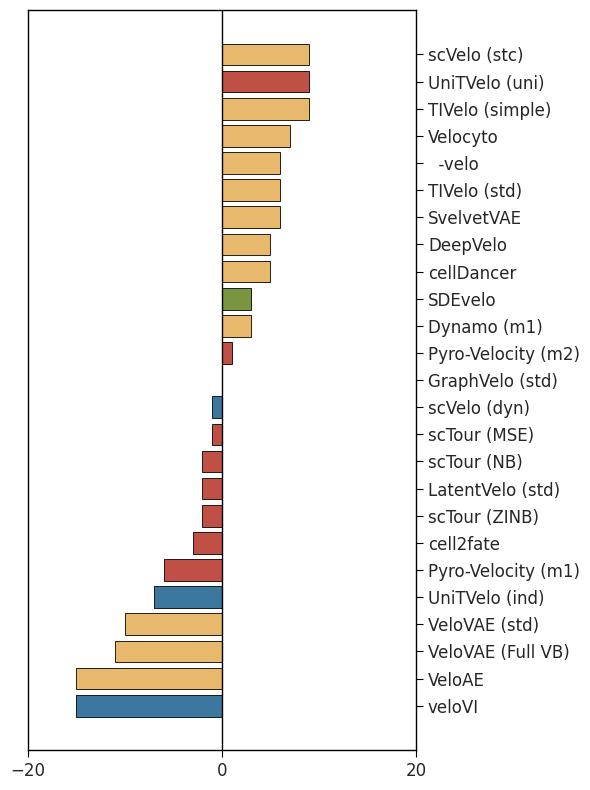

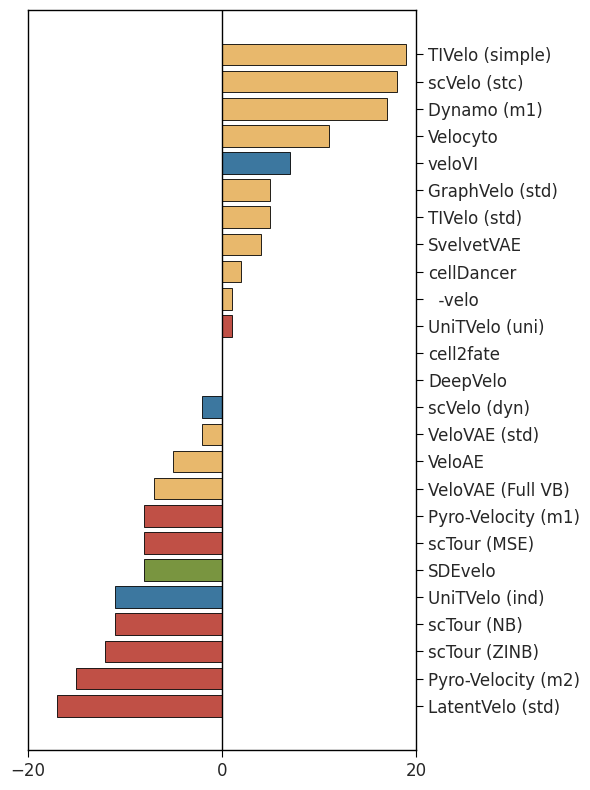

In [2]:
for dataset_name in DATASETS:
    diff_df = rank_compare_df[rank_compare_df["dataset"] == dataset_name].copy()
    diff_df["rank_diff"] = diff_df["direction_rank"] - diff_df["temporal_rank"]
    diff_df = diff_df.sort_values("rank_diff", ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(6, 8))
    bar_colors = diff_df["class"].map(class_colors)
    y_pos = np.arange(len(diff_df))
    ax.barh(
        y_pos,
        diff_df["rank_diff"],
        color=bar_colors,
        edgecolor="black",
        linewidth=0.6,
    )
    ax.axvline(0, color="black", linewidth=1)

    ax.set_xlim(-20, 20)
    ax.set_xticks([-20, 0, 20])
    ax.set_yticks(y_pos)
    ax.set_yticklabels(diff_df["Method_mapped"], fontsize=12)
    ax.invert_yaxis()
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=12)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        length=5,
        color="black",
        top=False,
        right=True,
        bottom=True,
        left=False,
        labelright=True,
        labelleft=False,
    )

    plt.tight_layout()
    plt.savefig(
        DIFF_RANK_SVG_TEMPLATE.format(dataset=dataset_name),
        format="svg",
        bbox_inches="tight",
        dpi=150,
    )
    plt.show()
    plt.close(fig)
